# Lecture 9: PyTorch Fundamentals - Tensors, Datasets, and Training Preparation

How to "read" this lecture notebook
<details>
<summary>click to expand</summary>

As you go through this notebook (or any notebook for this class), you will encounter new concepts and python code that implements them -- just like you would see in a textbook. Of course, in a textbook, it's easy to read code and an explanation of what it does and think that you understand it.
<br />

### Learn by doing
But this notebook is different from a textbook because it allows you to not just read the code, but play with it. **You can and should try out changing the code that you see**. In fact, in many places throughout this reading notebook, you will be asked to write your own code to experiment with a concept that was just covered. This is a form of "active reading" and the idea behind it is that we really learn by **doing**. 
<br />

### Change everything
But don't feel limited to only change code when I prompt you. This notebook is your learning environment and your playground. I encourage you to try changing and running all the code throughout the notebook and even to **add your own notes and new code blocks**. Adding comments to code to explain what you are testing, experimenting with or trying to do is really helpful to understand what you were thinking when you revisit it later. 
<br />

### Make this notebook your own
Make this notebook your own. Write your questions and thoughts. At the end of every reading notebook, I will ask the same set of questions to try to elicit your questions, reaction and feedback. When we review the reading notebook in class, I encourage you to share!

</details>

## Learning Objectives

By the end of this lecture, you will be able to:
- Understand PyTorch tensor operations and their relationship to NumPy arrays
- Learn how to create and manipulate tensors for machine learning tasks
- Master PyTorch's Dataset and DataLoader classes for data preparation
- Understand the components needed before training a neural network
- Implement basic training loops from scratch

# 9.0 Code Preface

In [2]:
import sys
!{sys.executable} -m pip install torch numpy matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

We should also see what version of PyTorch we have installed and what device we have available for computations (CPU or GPU). This answer will differ for each of you, as you are running this no your laptop.

In [4]:
# Let's check what version of PyTorch we have and whether GPU is available
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cpu
CUDA available: False


# 9.1 Introduction to PyTorch

<img alt="Maverick inverted dive" src="../images/L09_topgun_inverted.png" width="1000" style="display:block;">
<font size=2>Maverick (rocking a unibrow) explains that he was in a 4-gee, inverted dive with a MiG-28 to "communicate" in <i>Top Gun (1986)</i></font>

Before you can engage in any dogfight, you need to know your aircraft inside and out. PyTorch is our F-14 Tomcat for deep learning—a powerful, responsive framework that lets us build and train neural networks with precision.

PyTorch is one of the two dominant deep learning frameworks (alongside TensorFlow). It was developed by Facebook's AI Research lab and has become the **preferred choice for research** and increasingly for production.

**Why PyTorch?**
- **Pythonic**: Feels natural if you know Python and NumPy
- **Pedagogical**: You can see exactly what's happening at each step, making it easier to learn and debug
- **SoTa-friendly**: Most new research uses PyTorch, helping practitioners keep up with state of the art
- **Growing industry adoption**: Used at many AI-leading companies like OpenAI, Microsoft, and Meta

# 9.2 Tensor Basics

## What is a Tensor?

A **tensor** is just a fancy name for a multi-dimensional array. If you know NumPy, you already know most of what you need:

| NumPy | PyTorch | Math Name |
|-------|---------|----------|
| 0-D array | 0-D tensor | Scalar |
| 1-D array | 1-D tensor | Vector |
| 2-D array | 2-D tensor | Matrix |
| N-D array | N-D tensor | N-dimensional Tensor |

So why use PyTorch tensors instead of NumPy arrays?
1. **GPU acceleration**: Tensors can take advantage of the many parallel cores on GPUs for massive speedups
2. **Automatic differentiation**: Remember the gradient we talked about last time? Well PyTorch tracks operations for backpropagation and gradient accumulation.
3. **Neural network integration**: Built to work seamlessly with PyTorch's neural network modules

## Creating Tensors

There are many ways to create tensors -- making them from lists, nested lists, or existing NumPy arrays. Let's have a look at how:

In [5]:
# From a Python list
tensor_from_list = torch.tensor([1, 2, 3, 4, 5])
print(f"From list: {tensor_from_list}")
print(f"Shape: {tensor_from_list.shape}")
print(f"Data type: {tensor_from_list.dtype}")  # notice, we can use a tensor's dtype method to check the data type of the tensor's elements

From list: tensor([1, 2, 3, 4, 5])
Shape: torch.Size([5])
Data type: torch.int64


In [6]:
# 2D tensor (matrix) from nested lists
matrix = torch.tensor([[1, 2, 3], 
                       [4, 5, 6], 
                       [7, 8, 9]])
print(f"Matrix:\n{matrix}")
print(f"Shape: {matrix.shape}")  # We can use a tensor's shape attribute to get the dimensions of the tensor

Matrix:
tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])
Shape: torch.Size([3, 3])


Suppose we already have our data as a NumPy array (e.g., from a pandas dataframe column), we can easily convert it to a PyTorch tensor:


In [7]:
# From a NumPy array - the bridge between NumPy and PyTorch
numpy_array = np.array([1.0, 2.0, 3.0, 4.0])
tensor_from_numpy = torch.from_numpy(numpy_array)
print(f"From NumPy: {tensor_from_numpy}")
print(f"Data type: {tensor_from_numpy.dtype}")  # Note: inherits NumPy's float64

From NumPy: tensor([1., 2., 3., 4.], dtype=torch.float64)
Data type: torch.float64


We can also get a NumPy array back from a Pytorch tensor (if the tensor has gradient data, we would need to detach it first, though we won't cover that right now):

In [8]:
# Going back to NumPy
back_to_numpy = tensor_from_numpy.numpy()
print(f"Back to NumPy: {back_to_numpy}")
print(f"Type: {type(back_to_numpy)}")

Back to NumPy: [1. 2. 3. 4.]
Type: <class 'numpy.ndarray'>


<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    ⚠️
  </span>

  **Warning**: When converting between NumPy and PyTorch using `from_numpy()` or `.numpy()`, they **share the same memory**! Changing one will change the other. This is efficient but can lead to bugs if you're not careful. You can use `torch.tensor()` on a numpy array instead to create an independent copy.
  
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

Let's see the shared memory in action:

In [9]:
# Demonstration of shared memory
numpy_arr = np.array([1.0, 2.0, 3.0])
tensor = torch.from_numpy(numpy_arr)

print(f"Before: NumPy={numpy_arr}, Tensor={tensor}")

Before: NumPy=[1. 2. 3.], Tensor=tensor([1., 2., 3.], dtype=torch.float64)


In [10]:
# Modify the tensor
tensor[0] = 99.0

print(f"After:  NumPy={numpy_arr}, Tensor={tensor}")  # Both changed!

After:  NumPy=[99.  2.  3.], Tensor=tensor([99.,  2.,  3.], dtype=torch.float64)


## Common Ways to Initialize Tensors

Just like in NumPy, PyTorch has built-in functions for common tensor patterns:

In [11]:
# Zeros - great for initializing outputs or placeholders
zeros = torch.zeros(3, 4)  # 3 rows, 4 columns
print(f"Zeros (3x4):\n{zeros}")

Zeros (3x4):
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])


In [12]:
# Ones
ones = torch.ones(2, 3)
print(f"Ones (2x3):\n{ones}")

Ones (2x3):
tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [13]:
# Random values from uniform distribution [0, 1)
random_uniform = torch.rand(3, 3)
print(f"Random uniform:\n{random_uniform}")

Random uniform:
tensor([[0.1683, 0.0946, 0.9162],
        [0.4424, 0.6841, 0.0364],
        [0.5321, 0.0922, 0.7940]])


In [14]:
# Random values from standard normal distribution (mean=0, std=1)
random_normal = torch.randn(3, 3)
print(f"Random normal:\n{random_normal}")

Random normal:
tensor([[ 0.2313,  0.9044, -1.5586],
        [-0.1976,  0.6982,  0.0753],
        [ 0.2986,  1.6386,  0.8162]])


In [15]:
# Identity matrix - useful for linear algebra
identity = torch.eye(4)
print(f"Identity (4x4):\n{identity}")

Identity (4x4):
tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])


In [16]:
# Range of values (like np.arange)
range_tensor = torch.arange(0, 10, 2)  # start, end, step
print(f"Range: {range_tensor}")

# Linearly spaced values (like np.linspace)
linspace_tensor = torch.linspace(0, 1, 5)  # start, end, number of points
print(f"Linspace: {linspace_tensor}")

Range: tensor([0, 2, 4, 6, 8])
Linspace: tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


## Tensor Data Types

PyTorch supports various data types. The most common for deep learning are:

| Type | Description | When to Use |
|------|-------------|-------------|
| `torch.float32` | 32-bit floating point | Default for neural networks |
| `torch.float64` | 64-bit floating point | High precision (usually unnecessary) |
| `torch.int64` | 64-bit integer | Labels, indices |
| `torch.bool` | Boolean | Masks, conditions |

In [17]:
# Specifying data type at creation
float_tensor = torch.tensor([1, 2, 3], dtype=torch.float32)
int_tensor = torch.tensor([1, 2, 3], dtype=torch.int64)
bool_tensor = torch.tensor([True, False, True], dtype=torch.bool)

print(f"Float: {float_tensor}, dtype={float_tensor.dtype}")
print(f"Int: {int_tensor}, dtype={int_tensor.dtype}")
print(f"Bool: {bool_tensor}, dtype={bool_tensor.dtype}")

Float: tensor([1., 2., 3.]), dtype=torch.float32
Int: tensor([1, 2, 3]), dtype=torch.int64
Bool: tensor([ True, False,  True]), dtype=torch.bool


If we want to convert a tensor, we can use the `.to()` method to change its data type, but more commonly you see people use the specific type methods like `.float()`, `.int()` or `.long()`, etc. to convert to a specific type:

In [18]:
# Converting types
original = torch.tensor([1, 2, 3])
print(f"Original dtype: {original.dtype}")

as_float = original.float()  # or original.to(torch.float32)
print(f"As float: {as_float}, dtype={as_float.dtype}")

Original dtype: torch.int64
As float: tensor([1., 2., 3.]), dtype=torch.float32


<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    🛠️
  </span>

  **Note**: You will often see practitioners use `torch.float16` (half precision) or `torch.bfloat16` instead of `torch.float32`. Why? A model with 1 billion parameters in float32 requires ~4GB of GPU RAM. The same model in float16 requires only ~2GB. This **mixed precision training** technique lets you train larger models on GPUs with limited memory, often with minimal impact on accuracy. Modern GPUs (like NVIDIA's Tensor Cores) are actually optimized for these lower precision operations, making training faster too!
  
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

## Tensor Operations

<img alt="Short Round, Indy, Willie on  mine cart controls" src="../images/L09_indy_minecart.png" style="display:block;">
<font size=2>Indiana Jones, Short Round and Willie in the minecart chase in <i>Indiana Jones and the Temple of Doom (1984)</i></font>

Tensors often **change shape** as they pass through a neural network. If you aren't focused, you can lose track of which dimension is which and how they change as they pass through multiple layers of a neural network (like Indy navigating the mine). We need to master the fundamental operations of tensors. Let's look at the essential operations.

### Element-wise Operations

**Element-wise operations** are those that combine the elements of two tensors of the same shape by just operating on the corresponding element in the same position. For example, adding two 2x3 tensors element-wise would just take the sum of the elements in each position.

Simple operations (element-wise adding, subtracting, multiplying, etc.) work as you would expect:

In [19]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

# Basic arithmetic - element by element
print(f" {a + b = }")
print(f" {a - b = }")
print(f" {a * b = }")  # Element-wise multiplication
print(f" {a / b = }")
print(f"{a ** 2 = }")  # Element-wise to a constant power
print(f"{a ** b = }")  # Element-wise to the power of another tensor

 a + b = tensor([5., 7., 9.])
 a - b = tensor([-3., -3., -3.])
 a * b = tensor([ 4., 10., 18.])
 a / b = tensor([0.2500, 0.4000, 0.5000])
a ** 2 = tensor([1., 4., 9.])
a ** b = tensor([  1.,  32., 729.])


Some **common element-wise operations in ML** include the absolute value, square root, exponentiation, and logairthm:

In [20]:
# Common mathematical functions
x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])

print(f"{'x':>25} = {x}")
print(f"{'torch.abs(x)':>25} = {torch.abs(x)}")
print(f"{'torch.sqrt(torch.abs(x))':>25} = {torch.sqrt(torch.abs(x))}")
print(f"{'torch.exp(x)':>25} = {torch.exp(x)}")
print(f"{'torch.log(torch.exp(x))':>25} = {torch.log(torch.exp(x))}")

                        x = tensor([-2., -1.,  0.,  1.,  2.])
             torch.abs(x) = tensor([2., 1., 0., 1., 2.])
 torch.sqrt(torch.abs(x)) = tensor([1.4142, 1.0000, 0.0000, 1.0000, 1.4142])
             torch.exp(x) = tensor([0.1353, 0.3679, 1.0000, 2.7183, 7.3891])
  torch.log(torch.exp(x)) = tensor([-2., -1.,  0.,  1.,  2.])


### Reduction Operations

You can reduce a particular dimension of a tensor by applying an aggregation function on it (sum, min, max, etc.).  This replaces all the numbers along that dimension (e.g., row, col) with a single number.

Here are some examples of operations that reduce a tensor along one or more dimensions:

In [21]:
matrix = torch.tensor([[1.0, 2.0, 3.0],
                       [4.0, 5.0, 6.0]])
print(f"Matrix:\n{matrix}")
print(f"Shape: {matrix.shape}")

Matrix:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
Shape: torch.Size([2, 3])


In [22]:
# Sum
print(f"Sum of all: {matrix.sum()}")          # Sum of all elements
print(f"Sum along rows (dim=0): {matrix.sum(dim=0)}")    # Sum each column
print(f"Sum along cols (dim=1): {matrix.sum(dim=1)}")    # Sum each row

Sum of all: 21.0
Sum along rows (dim=0): tensor([5., 7., 9.])
Sum along cols (dim=1): tensor([ 6., 15.])


In [23]:
# Mean, min, max
print(f"Mean: {matrix.mean()}")
print(f"Min: {matrix.min()}")
print(f"Max: {matrix.max()}")

# argmax returns the index of the maximum value
print(f"Argmax (flat): {matrix.argmax()}")  # Index in flattened tensor
print(f"Argmax per row: {matrix.argmax(dim=1)}")  # Index of max in each row (no longer flattened)

Mean: 3.5
Min: 1.0
Max: 6.0
Argmax (flat): 5
Argmax per row: tensor([2, 2])


### Matrix Operations
<img alt="The many matrices in the matrix" src="../images/L09_neo_sees_matrix.gif"  width="700" style="display:block;">
<font size=2>Neo <b><i>sees</b></i> in <i>The Matrix (1999).</i> Just like the movie, it turns out there is more than one matrix, but the others suck.</font>

We can think of a matrix as applying a transformation to a set of numbers and getting another set of numbers back again.

 **Matrix multiplication** chains transformations together. If matrix `B` reshapes data from one size to another, and matrix `A` reshapes it further, then the matrix multiplication `A @ B` gives you a single matrix that does both steps at once—like combining two assembly line stations into one.

Matrix multiplication is fundamental to neural networks. Every layer essentially performs matrix multiplication (along with nonlinear activation)!



In [24]:
# Matrix multiplication
A = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])  # 2x3 matrix

B = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0],
                  [5.0, 6.0]])  # 3x2 matrix
print(f"A:\n{A}")  # 2x3
print(f"A shape: {A.shape}")  # 2x3
print(f"\nB:\n{B}")  # 3x2
print(f"B shape: {B.shape}")  # 3x2

A:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
A shape: torch.Size([2, 3])

B:
tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])
B shape: torch.Size([3, 2])


There's a few different ways to do matrix multiplication, but `@` method is preferred for its readability and simplicity:

In [25]:
# Three ways to do matrix multiplication - all are equivalent, @ is preferred
result1 = A @ B  # Python 3.5+ operator
result2 = torch.matmul(A, B)
result3 = torch.mm(A, B)  # Only for 2D tensors


# Matrix multiplication of A,B results in a 2x2 (Notice, for a matrix multiplication to make sense, the "inner" dimensions must match!)
print(f"A @ B:\n{result1}")
print(f"A @ B shape: {result1.shape}")

A @ B:
tensor([[22., 28.],
        [49., 64.]])
A @ B shape: torch.Size([2, 2])



<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    🧠
  </span>
Matrix multiplication reduces or <font color="blue">"sums over" the inner dimension shared by the two matrices</font>.

For example, multiplying a $(2 \times \textbf{3})$ matrix by a $(\textbf{3} \times 1)$ matrix results in a $(2 \times 1)$ matrix. The inner dimension of size 3 is combined through summation, leaving the outer dimensions in the result. You cannot just matrix multiply any arbitrary matrices. If the inner dimension doesn't match, you will get an error.

  
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

If you try to matrix multiply two matrices with inner dimensions that don't match, you get an error:

In [26]:
A = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])  # 2x3 matrix

C = torch.tensor([[2.0, 3.0],
                  [5.0, 6.0]])  # 2x2 matrix

try:
    A @ C  # (2 X 3) @ (2 X 2) --> the inner dimensions do not match
except RuntimeError as e:
    print(f"Error: {e}")  # Should raise an error due to shape mismatch

Error: mat1 and mat2 shapes cannot be multiplied (2x3 and 2x2)


Matrix multiplication is very common in neural networks, often as a 2D <font color="blue">matrix of weights</font> multiplying a 1D <font color="blue">vector of input features</font>:

In [27]:
# Matrix-vector multiplication (very common in neural networks!)
weights = torch.tensor([[1.0, 2.0, 3.0],
                        [4.0, 5.0, 6.0]])  # 2x3 weight matrix

input_vector = torch.tensor([1.0, 1.0, 1.0])  # 3 input features

output = weights @ input_vector  # 2x3 @ 3 -> 2
print(f"Weights shape: {weights.shape}")
print(f"Input shape: {input_vector.shape}")
print(f"Output: {output}, shape: {output.shape}")

Weights shape: torch.Size([2, 3])
Input shape: torch.Size([3])
Output: tensor([ 6., 15.]), shape: torch.Size([2])


<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    💡
  </span>

  **Key Insight**: A neural network layer is essentially: `output = activation(weights @ input + bias)`. That's it! All the complexity comes from stacking these simple operations.
  
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

### Reshaping Tensors

You'll often need to reshape tensors to match expected dimensions. PyTorch offers two main methods: `reshape()` and `view()`.

**`view()` vs `reshape()`**: Both change the shape of a tensor without changing its data, but they differ in an important way:
- **`view()`** requires the tensor to be *contiguous* in memory—meaning the elements are stored in a single, unbroken block in the order you'd expect. If your tensor isn't contiguous (e.g., after a transpose), `view()` will throw an error.
- **`reshape()`** is more flexible—it will return a view if possible, but if the tensor isn't contiguous, it will automatically make a copy so the operation succeeds.

**Rule of thumb**: Use `reshape()` when you just want it to work. Use `view()` when you want to be sure you're not accidentally copying data (which matters for performance with large tensors).

In [28]:
# Original tensor
x = torch.arange(12)  # [0, 1, 2, ..., 11]
print(f"Original: {x}, shape: {x.shape}")

Original: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]), shape: torch.Size([12])


In [29]:
# Reshape to different dimensions
reshaped = x.reshape(3, 4)  # 3 rows, 4 columns
print(f"Reshaped (3x4):\n{reshaped}")

Reshaped (3x4):
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])


In [30]:
# view() does the same but requires contiguous memory
viewed = x.view(4, 3)  # 4 rows, 3 columns
print(f"Viewed (4x3):\n{viewed}")

Viewed (4x3):
tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]])


Sometimes you may easily know some of the dimensions you want in your reshaped result, but not all (e.g., I want 4 rows; I don't want to do math to figure out the columns). In this case, we can use `-1` as an argument:

In [31]:
# Start with a simple 1D tensor
x = torch.arange(24)
print(x)
print(f"Original shape: {x.shape}")

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23])
Original shape: torch.Size([24])


In [32]:
# Using -1 to infer dimension
reshaped = x.reshape(4, -1) #  "I want 4 rows, figure out the columns"

print(f'{reshaped}\n')
print(f"reshape(4, -1) produced a tensor of shape: {reshaped.shape}")  # Will be 4x6

tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11],
        [12, 13, 14, 15, 16, 17],
        [18, 19, 20, 21, 22, 23]])

reshape(4, -1) produced a tensor of shape: torch.Size([4, 6])


In [33]:
# "I want 2x3x?, figure out the last dimension"
reshaped_3d = x.reshape(2, 3, -1)
print(f"Reshaped to (2, 3, -1): {reshaped_3d.shape}")  # Will be 2x3x4 -- obviously we can't print this out to the screen

Reshaped to (2, 3, -1): torch.Size([2, 3, 4])


Other common operations that change the shape of a tensor are transpose (`.T`), `squeeze()` and `unsqueeze()`
- `.T` or `.transpose()` swaps dimensions (e.g., for a 2D array, this would turn rows into columns). The former only works for 2D tensors.
- `squeeze()` removes dimension of size 1 at the specified position
- `unsqueeze()` adds dimension of size 1 at the specified position

Let's look at each of these in turn.

Transpose:

In [34]:
# Start with a 2x3 matrix
matrix = torch.arange(6).reshape(2, 3)
print(f"Original (2x3):\n{matrix}")

Original (2x3):
tensor([[0, 1, 2],
        [3, 4, 5]])


In [35]:
# Transpose: swap dimensions
transposed = matrix.T  # or matrix.transpose(0, 1)
print(f"Transposed (3x2):\n{transposed}")

Transposed (3x2):
tensor([[0, 3],
        [1, 4],
        [2, 5]])


Squeeze and unsqueeze can also be demonstrated (but the visual clue can sometimes be subtle). Pay attention to the square brackets in the tensors below:

In [36]:
# Start with a 1D tensor
x = torch.tensor([1, 2, 3])
print(f'Original:\n{x}\tshape: {x.shape}')

Original:
tensor([1, 2, 3])	shape: torch.Size([3])


In [37]:
# Squeeze and unsqueeze: add/remove dimensions of size 1
unsqueezed = x.unsqueeze(0)  # Add dimension at position 0
print(f'Unsqueezed at 0:\n{unsqueezed}\tshape: {unsqueezed.shape}') # Now 1x3

Unsqueezed at 0:
tensor([[1, 2, 3]])	shape: torch.Size([1, 3])


It's less subtle when its not the first dimension:

In [38]:
unsqueezed = x.unsqueeze(1)  # Add dimension at position 1
print(f"Unsqueezed at 1:\n{unsqueezed}\tshape: {unsqueezed.shape}")  # Now 3x1

Unsqueezed at 1:
tensor([[1],
        [2],
        [3]])	shape: torch.Size([3, 1])


In [39]:
# Remove dimensions of size 1
y = torch.tensor([[[1, 2, 3]]])  # Shape: 1x1x3
print(f"Before squeeze:\n{y}\tshape: {y.shape}\n")

print(f"After squeeze(0):\n{y.squeeze(0)}\tshape: {y.squeeze(0).shape}")  # Squeeze out dimension=0, leaving a 1x3

Before squeeze:
tensor([[[1, 2, 3]]])	shape: torch.Size([1, 1, 3])

After squeeze(0):
tensor([[1, 2, 3]])	shape: torch.Size([1, 3])


You can also apply squeeze with no arguments to get rid of all dimensions of size 1:

In [40]:
y = torch.tensor([1,2,3]).unsqueeze(1).unsqueeze(0)
print(f"Before squeeze:\n{y}\tshape: {y.shape}\n")
print(f"After squeeze:\n{y.squeeze()}\tshape: {y.squeeze().shape}")  # Now just 3 ; notice how squeeze removes all dimensions of size 1 when no arguments are passed

Before squeeze:
tensor([[[1],
         [2],
         [3]]])	shape: torch.Size([1, 3, 1])

After squeeze:
tensor([1, 2, 3])	shape: torch.Size([3])


### Indexing and Slicing

Indexing and slicing allow you to select a particular entry or a range of entries in the array. It works just like NumPy.

In [41]:
matrix = torch.arange(12).reshape(3, 4)
print(f"Matrix:\n{matrix}")

Matrix:
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])


In [42]:
# Single element
print(f"Element [1, 2]: {matrix[1, 2]}")

Element [1, 2]: 6


In [43]:
# Entire row (implicit slice)
print(f"Row 0: {matrix[0]}") # notice, this does not give me a single number (like indexing from a flat tensor would) but rather a 1D tensor representing that row

Row 0: tensor([0, 1, 2, 3])


In [44]:
# Entire column
print(f"Column 1: {matrix[:, 1]}") # The ":" (slice) means "take all elements along this dimension" - in this case, all rows for column 1

Column 1: tensor([1, 5, 9])


In [45]:
# Slice: rows 0-1, columns 1-3
print(f"Slice [0:2, 1:3]:\n{matrix[0:2, 1:3]}")

Slice [0:2, 1:3]:
tensor([[1, 2],
        [5, 6]])


In [46]:
# Boolean indexing
values = torch.tensor([1.0, -2.0, 3.0, -4.0, 5.0, 6.0])
positive_mask = values > 0
print(f"Values: {values}")
print(f"Positive mask: {positive_mask}")
print(f"Positive values: {values[positive_mask]}")

Values: tensor([ 1., -2.,  3., -4.,  5.,  6.])
Positive mask: tensor([ True, False,  True, False,  True,  True])
Positive values: tensor([1., 3., 5., 6.])


<font color="blue">Pytorch likes to remember the shape of tensors whenever possible.</font>

If our original `values` tensor had some shape that wasn't simply 1D. We can still index with a boolean mask, however, the mask must have same shape as the tensor we are applying it to. The result of the boolean mask will be a tensor of the same shape as the original, but with `True` values where the condition is met and `False` values elsewhere. When we index the original tensor with this boolean mask, we get back a 1D tensor containing only the values where the mask was `True`.  Have a look:

In [47]:
values = values.reshape(3,-1)  # Suppose our original tensore was a 3x2 matrix
positive_mask = values > 0  # positive_mask will have the same shape as values
print(f"values:\n{values}")
print(f"\npositive_mask:\n{positive_mask}")
print(f"\nvalues[positive_mask]:\n{values[positive_mask]}")

values:
tensor([[ 1., -2.],
        [ 3., -4.],
        [ 5.,  6.]])

positive_mask:
tensor([[ True, False],
        [ True, False],
        [ True,  True]])

values[positive_mask]:
tensor([1., 3., 5., 6.])


If you think for a second about the above operation, you will realize it is inevitable. Selecting only the elements from `values` where the mask is `True` necessarily means we have to "lose the shape". 

### Broadcasting

<img alt="Array broadcasting" src="../images/L09_broadcasting.png"  width="500" style="display:block;">
<font size=2>Broadcasting stretches and <i>fills in the blanks</i> to make operations work.</font>


**Broadcasting** lets you do math between arrays of different shapes by automatically "stretching" the smaller one to match the larger one. For example, if you add a single number to a matrix, that number gets added to every element; if you add a row vector to a matrix, that row gets added to every row.

(if you're familiar with NumPy, the broadcast rules are the same with pytorch)

Let's look at some examples of how this works to get a feel for it:

In [48]:
# Start with a simple matrix
matrix = torch.ones(2, 3)
print(matrix)

tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [49]:
# Multiplying by a scalar broadcasts to all elements of the matrix
result = matrix * 5
print(f"Matrix * 5:\n{result}")

Matrix * 5:
tensor([[5., 5., 5.],
        [5., 5., 5.]])


In [50]:
# Suppose I start with a matrix and a row vector
matrix = torch.ones(3, 4)
row_vector = torch.tensor([1, 2, 3, 4])  # Shape: (4,)
print(f"Matrix:\n{matrix}\n")
print(f"Row vector:\n{row_vector}")

Matrix:
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

Row vector:
tensor([1, 2, 3, 4])


In [51]:
# Row vector broadcasts across rows
result = matrix + row_vector
print(f"matrix + row vector:\n{result}")
print(f"\nPyTorch accomplished the above by effectively stretching the row vector to match the matrix shape for broadcasting:\n{torch.broadcast_to(row_vector, (3, 4))}")

matrix + row vector:
tensor([[2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.]])

PyTorch accomplished the above by effectively stretching the row vector to match the matrix shape for broadcasting:
tensor([[1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4]])


In [52]:
# The same idea works for broadcasting a column vector across columns
matrix = torch.ones(3, 4)
col_vector = torch.tensor([[10], [20], [30]])  # Shape: (3, 1)
print(f"Matrix:\n{matrix}\n")
print(f"Column vector:\n{col_vector}\n")
result = matrix + col_vector
print(f"matrix + column vector:\n{result}")
print(f"\nPyTorch effectively stretched the column vector to match the matrix shape for broadcasting:\n{torch.broadcast_to(col_vector, (3, 4))}")

Matrix:
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

Column vector:
tensor([[10],
        [20],
        [30]])

matrix + column vector:
tensor([[11., 11., 11., 11.],
        [21., 21., 21., 21.],
        [31., 31., 31., 31.]])

PyTorch effectively stretched the column vector to match the matrix shape for broadcasting:
tensor([[10, 10, 10, 10],
        [20, 20, 20, 20],
        [30, 30, 30, 30]])


<!-- Start Exercise 9.1 -->
<hr/>
<img src="../images/stop_right_margin.png" align="left">

<font size=3 color="darkred"> Exercise 9.1: Tensor Operations </font>
<div class="inclass_exercise_body" style="padding-left: 130px; width: 85%; text-align: justify;text-align-last: left;">

Complete the following tensor operations:

1. Create two 3x3 matrices `A` and `B` filled with random values
2. Compute their matrix product (not element-wise!)
3. Find the mean of the resulting matrix
4. Create a 1D tensor of 12 elements and reshape it to 3x4 matrix

</div>

In [53]:
# Exercise 9.1: Tensor Operations

# Import torch and numpy
import torch
import numpy as np


# 1. Create two 3x3 random matrices
A = torch.tensor([[1.0, 2.0, 3.0],
                  [7.0, 8.0, 9.0],
                  [4.0, 5.0, 6.0]]) 
B = torch.tensor([[5.0, 7.0, 9.0],
                  [6.0, 8.0, 6.0],
                  [3.0, 5.0, 1.0]]) 

# 2. Matrix multiply your two matrices
product = A @ B  

# 3. Find the mean of the resulting matrix
mean_value = product.mean()
  
# Start with a simple 1D tensor
x = torch.arange(12)
print(x)
print(f"Original shape: {x.shape}")

reshaped_x = x.reshape(3, 4)

# Print results
print(f"A:\n{A}")
print(f"B:\n{B}")
print(f"A @ B:\n{product}")
print(f"Mean: {mean_value}")
print(f"Reshaped: {reshaped_x.shape}")

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
Original shape: torch.Size([12])
A:
tensor([[1., 2., 3.],
        [7., 8., 9.],
        [4., 5., 6.]])
B:
tensor([[5., 7., 9.],
        [6., 8., 6.],
        [3., 5., 1.]])
A @ B:
tensor([[ 26.,  38.,  24.],
        [110., 158., 120.],
        [ 68.,  98.,  72.]])
Mean: 79.33333587646484
Reshaped: torch.Size([3, 4])


<hr/>
<!-- End Exercise 9.1 -->

## Moving Tensors Between CPU and GPU

One of PyTorch's key features is seamless GPU acceleration. Here's how to move tensors between devices (this might not work on your laptop if you don't have a GPU (mine does, so I will demo it):

In [54]:
# Check what device a tensor is on using .device
x = torch.rand(3, 3)
print(f"Default device: {x.device}")

Default device: cpu


In [55]:
# Set up device-agnostic code (works with or without GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [56]:
# Move tensor to device with the .to(device) method
x = torch.rand(3, 3)
print(f"Before move, tensor device: {x.device}")
x = x.to(device)  # Move to GPU if available
print(f"After move, tensor device: {x.device}")  # if you don't have a GPU, this will seem to have no effect

Before move, tensor device: cpu
After move, tensor device: cpu


It is of course possible to create a tensor already on a specified device:

In [57]:
# Create tensor directly on device
y = torch.rand(3, 3, device=device)
print(f"Created on: {y.device}")

Created on: cpu


<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 30pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    ⚠️
  </span>

**Tensor Gotcha**: You cannot perform operations on tensors that live on different devices!  You must move both tensors to the same device first.
  
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

Let's try to add a tensor on the CPU to one on the GPU and see what happens (again this demo will only work if you have a GPU):

In [58]:
# Operations must be on the same device!  (this demonstration may produce no result if your machine has no GPU)
# This will fail if tensors are on different devices:
try:
    x = x.to("cpu") # Intentionally move x to CPU to demonstrate error
    y = y.to(device) # Move y to default device (may be GPU if supported)
    z = x + y  # Both on same device, so this works
    print(f"Result device: {z.device}")
except RuntimeError as e:
    print(f"Error: {e}")  # In case of device mismatch

Result device: cpu


In [59]:
z = x.to(device) + y.to(device) # Ensure both are on the same device before adding
print(f"Result of addition on device:\n{z}")

Result of addition on device:
tensor([[0.9773, 0.2759, 0.5522],
        [0.7961, 0.0637, 1.0821],
        [1.2815, 1.2845, 1.2001]])


If we want a NumPy array from a tensor on the GPU, **we have to move it back to the CPU first** (if the tensor had gradient data -- this one does not -- we would also need to detach it first, but again, we'll hold off on talking about that for now):

In [60]:
try:
    z.numpy()
except Exception as e:
    print(f"Error: {e}")

Move z back to the cpu and then convert to NumPy:

In [61]:
# Move back to CPU (needed before converting to NumPy)
z_cpu = z.cpu()
z_numpy = z_cpu.numpy()  # Now we can convert to NumPy
print(f"As NumPy:\n{z_numpy}")

As NumPy:
[[0.9773409  0.27589887 0.55222183]
 [0.79607534 0.06374592 1.0821443 ]
 [1.2815319  1.2844697  1.2001278 ]]


<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    💡
  </span>

  **Best Practice**: Always set a device variable at the top of your code using `device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')`. This makes your code work on any machine regardless of whether it has a GPU.
  
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

# 9.3 Datasets and DataLoaders

<img alt="How Robocop gets his data" src="../images/L09_robocop_data_spike.png"  width="800" style="display:block;">
<font size=2>RoboCop gets his data with a spike in <i>RoboCop (1987)</i>. You'll get yours with a DataLoader.</font>

Data comes in a variery of formats, but we often boil it down into "just the numbers" before we input it into a neural network. To standardize how we do this and make our data useful for training *efficiently*, PyTorch provides the `Dataset` and `DataLoader` classes, which allow you to transform raw data into objects with built-in training functionality.

**Why not just use plain arrays?**
- **Batching**: Neural networks train on batches, not individual samples
- **Shuffling**: Random order prevents overfitting to data order
- **Parallel loading**: Load data in background while GPU trains
- **Memory management**: Only load what you need

## The Dataset Class

A `Dataset` is a container for your data. It answers the question: <font color="blue">How do I access one sample of my data?</font>. The dataset class class is **abstract**, which is another way of saying it is like an outline that you need to fill in (it has empty stub methods that are not implemented). PyTorch requires you to implement two methods:
- `__len__()`: Returns the total number of samples
- `__getitem__(idx)`: Returns one sample given an index

Let's define a dataset class based on `Dataset` and assume that our `features` and `labels` (or `targets`) are both numerical and can be stored as *(cast to)* tensors of floats:


In [62]:
# Let's create a simple dataset from scratch
class SimpleDataset(Dataset):
    """A simple dataset that assumes features and labels (targets) can be cast to floats and stores them as tensors."""
    
    def __init__(self, features, labels):
        """
        Args:
            features: numpy array or tensor of shape (n_samples, n_features)
            labels: numpy array or tensor of shape (n_samples,)
        """
        # Convert to tensors if needed
        if isinstance(features, np.ndarray):
            features = torch.from_numpy(features).float()
        if isinstance(labels, np.ndarray):
            labels = torch.from_numpy(labels).float()
            
        self.features = features
        self.labels = labels
        
    def __len__(self):
        """Return the total number of samples."""
        return len(self.features)
    
    def __getitem__(self, idx):
        """Return one sample (features, label) at the given index."""
        return self.features[idx], self.labels[idx]

**Note**: Since we have assumed that labels can be cast as `float`, <font color="blue">we can't use this class for label columns that are **categorical**</font>. We'll look at some examples like this later and define a different dataset class to handle those.

For now, let's see how to get from a pandas dataframe to a dataset object using this dataset class:

In [63]:
# First, we'll make a synthetic dataframe in pandas, like something you might usually start with 
import pandas as pd

np.random.seed(42)
n_samples = 100
n_features = 4
df = pd.DataFrame(np.random.randn(n_samples, n_features).round(3), columns=[f'feature_{i}' for i in range(n_features)])
df['label'] = (df['feature_0'] + df['feature_1'] > 0).astype(float) # Simple rule: positive if x0 + x1 > 0
df.head()

,feature_0,feature_1,feature_2,feature_3,label
0,0.497,-0.138,0.648,1.523,1.0
1,-0.234,-0.234,1.579,0.767,0.0
2,-0.469,0.543,-0.463,-0.466,1.0
3,0.242,-1.913,-1.725,-0.562,0.0
4,-1.013,0.314,-0.908,-1.412,0.0


So in this typical situation, or data is sitting in a pandas DataFrame and we want to transform it into a PyTorch dataset. We'll start by extracting the features (X) and labels (y) from the dataframe as pure NumPy arrays:

In [64]:
# Extract features (X) and labels (y) from the dataframe as pure NumPy arrays
X = df.drop(columns=["label"]).values  # X will be a mult-dimensional NumPy array of "features"
y = df["label"].values # y will be a 1D NumPy array of "labels" 

Now we will create a Pytorch dataset object from our features and labels:

In [65]:
# Create dataset
dataset = SimpleDataset(X, y)

print(f"Dataset size: {len(dataset)}")
print(f"First sample: features={dataset[0][0]}, label={dataset[0][1]}")

Dataset size: 100
First sample: features=tensor([ 0.4970, -0.1380,  0.6480,  1.5230]), label=1.0


So far, so good, but not (yet) very useful. We need to be able to get batches of data from this dataset, and we need to be able to shuffle it and load it in parallel. For that, we need a DataLoader.

## The DataLoader Class

The `DataLoader` answers the question: <font color="blue">How do I get batches of data from my dataset?</font>. It is a powerful utility that takes a `Dataset` and provides:
- Batching (grouping samples together)
- Shuffling (randomizing order)
- Parallel data loading (multiple workers)

 Unlike the `Dataset`, the `DataLoader` is not abstract and is ready to use as is. You just need to pass it a dataset object and specify some parameters. Let's do that now:

In [66]:
# Create a DataLoader
batch_size = 16
dataloader = DataLoader(
    dataset, 
    batch_size=batch_size,
    shuffle=True  # Randomize order each epoch (each time we pass over all the data)
)

print(f"Number of batches: {len(dataloader)}")  # Calling len() on DataLoader gives the number of batches
print(f"Batch size: {dataloader.batch_size}")  # DataLoader objects store the batch size as an attribute
print(f"100 samples / 16 per batch = {100 / 16:.1f} batches") # If your number of smamples is not divisible by the batch size, the last batch will be smaller

Number of batches: 7
Batch size: 16
100 samples / 16 per batch = 6.2 batches


Let's iterate over batches and examine the shape of the features and labels for each batch:

In [67]:
# Iterate through the DataLoader
for batch_idx, (features_batch, labels_batch) in enumerate(dataloader):  # enumerate() gives a tuple (index, value); here value is a tuple of (features, labels)
    print(f"Batch {batch_idx}: features shape = {features_batch.shape}, labels shape = {labels_batch.shape}")

Batch 0: features shape = torch.Size([16, 4]), labels shape = torch.Size([16])
Batch 1: features shape = torch.Size([16, 4]), labels shape = torch.Size([16])
Batch 2: features shape = torch.Size([16, 4]), labels shape = torch.Size([16])
Batch 3: features shape = torch.Size([16, 4]), labels shape = torch.Size([16])
Batch 4: features shape = torch.Size([16, 4]), labels shape = torch.Size([16])
Batch 5: features shape = torch.Size([16, 4]), labels shape = torch.Size([16])
Batch 6: features shape = torch.Size([4, 4]), labels shape = torch.Size([4])


Notice how the last batch is different (because we had 100 samples which does not divide evenly into 16 batches; the last batch is smaller). In general, <font color="blue">the batch dimension (dim 0) of data will vary</font>.

## Creating Train/Validation/Test Splits

In machine learning, we typically split our data into three sets:
- **Training set**: What the model learns from
- **Validation set**: For tuning hyperparameters and monitoring during training
- **Test set**: Final evaluation (only used once!)

*Importantly, validation/test data is never seen when training!*

Let's start with a dateset, specify the sizes of training/test/validation, and split it:

In [68]:
from torch.utils.data import random_split

# Create full dataset
full_dataset = SimpleDataset(X, y) # we defined X,y above

# Split sizes (80% train, 10% val, 10% test)
n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val  # Remainder goes to test

print(f"Total: {n_total}, Train: {n_train}, Val: {n_val}, Test: {n_test}")

# Random split
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, 
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)  # For reproducibility
)


Total: 100, Train: 80, Val: 10, Test: 10


Now we have three different datasets (`train_dataset`, `val_dataset`, `test_dataset`).  We can make  `DataLoader()` objects for each:

In [69]:
# Create DataLoaders for each split
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)  # No need to shuffle val/test
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 5
Val batches: 1
Test batches: 1


## Using Built-in Datasets (torchvision)

PyTorch provides many pre-built datasets through `torchvision`. Let's look at the classic MNIST dataset:

In [70]:
# Load the MNIST dataset as an example of a pytorch built-in dataset
#  Later on, we'll use this dataset for training neural networks

from torchvision import datasets, transforms


# MNIST dataset has an option to specify a transform function that will be applied to each image when it is loaded
#  Here, we convert the PIL image to a tensor and normalize it
#  We won't actually use this now, but it's a good example of typical preprocessing
# Define transforms (preprocessing steps)
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert PIL image to tensor, scales to [0, 1]
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std hardcoded here for normalization
])

# Download and load MNIST (this will download if not already present)
mnist_train = datasets.MNIST(
    root='../data',  # Where to store the data
    train=True,     # Training set
    download=True,  # Download if not present
    transform=transform  # specify 
)

mnist_test = datasets.MNIST(
    root='../data',
    train=False,    # Test set
    download=True,
    transform=transform
)

print(f"Training samples: {len(mnist_train)}")
print(f"Test samples: {len(mnist_test)}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 7.61MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 455kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.32MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.9MB/s]

Training samples: 60000
Test samples: 10000


Let's look at a single sample from the dataset (image and label), to see what it looks like:

Image shape: torch.Size([1, 28, 28])
Label: 9


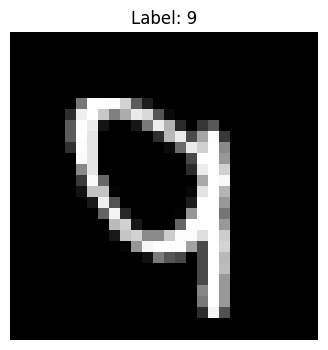

In [71]:
# Look at one sample (the image and its label) -- you can re-run this a few times (since the sample is randomly selected each time)
idx = torch.randint(0, len(mnist_train), (1,)).item()  # Randomly select an index from the training set
image, label = mnist_train[idx]  # Grab the element at the selected index
print(f"Image shape: {image.shape}")  # 1 channel (grayscale), 28x28 pixels
print(f"Label: {label}")

# Visualize
plt.figure(figsize=(4, 4))
plt.imshow(image.squeeze(), cmap='gray')  # Remove channel dimension for plotting
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

Now that the dataset is defined, we can create a dataloader to handle things like batching and shuffling:

In [72]:
# Create DataLoader for MNIST
mnist_loader = DataLoader(mnist_train, batch_size=64, shuffle=True)

In [73]:
# Get one batch
images, labels = next(iter(mnist_loader))
print(f"Batch of images shape: {images.shape}")  # 64 images, 1 channel, 28x28
print(f"Batch of labels shape: {labels.shape}")  # 64 labels

Batch of images shape: torch.Size([64, 1, 28, 28])
Batch of labels shape: torch.Size([64])


<!-- Start Exercise 9.2 -->
<hr/>
<img src="../images/stop_right_margin.png" align="left">

<font size=3 color="darkred"> Exercise 9.2: Build a Classification Dataset from a dataframe</font>
<div class="inclass_exercise_body" style="padding-left: 130px; width: 85%; text-align: justify;text-align-last: left;">

Let's make a <code>ClassificationDataset</code> class that can handle categorical targets (labels). This class should take a pandas DataFrame, a list of feature column names, and a target column name, and prepare the data for use with PyTorch.

Fill in the following steps in the constructor (`__init__`) method:

1. **Features**: Extract the features from the DataFrame and store as a PyTorch tensor `self.X`.
2. **Categorical Target**: Convert the target column to a categorical one `target_cat` using `pd.Categorical()`
3. **Target Codes**: Get the integer class labels from `target_cat.codes` and save them as a PyTorch tensor `self.y`.
4. **Class Names**: Get the names of the classes `target_cat.categories` and store as a list `self.classes`.

Test your implementation by creating a `ClassificationDataset` from the `bb_df` DataFrame and using a `DataLoader` to iterate through one batch.
</div>

In [74]:
%pip install torch torchvision


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [75]:
# Exercise 9.2: Build a Classification Dataset from a dataframe

# Imports and data loading repeated for convenience
from torch.utils.data import Dataset
import pandas as pd

# First, load the bluebikes sample dataframe. We will pass this to the custom Dataset class that you will create below
bb_df = pd.read_csv('../data/bluebikes_sample.csv')
bb_df.head()


# Create a custom Dataset class named ClassificationDataset based on Dataset
class ClassificationDataset(Dataset):
    def __init__(self, df: pd.DataFrame, feature_colnames: list, target_colname: str):
        # Many real-world datasets will not bother to store feature and target column names, but we will for transparency
        self.feature_names = feature_colnames
        self.target_name = target_colname
        # 1. Extract the features from the DataFrame and store as a PyTorch tensor self.X.

        # 2. Convert the target column to a categorical one target_cat using pd.Categorical()

        # 3. Convert target_cat.codes (the integer labels) to a tensor and store it as self.y

        # 4. Convert target_cat.categories to a list and store it as self.classes (these are names of the classes that correspond to the integer codes stored in self.y)

        pass
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

try:
    # Create dataset and dataloader
    dataset = ClassificationDataset(bb_df, ['tripduration', 'start_station_id', 'end_station_id', 'birth_year'], 'usertype')
    print(f"Dataset size: {len(dataset)}")
    print(f"Dataset feature names: {dataset.feature_names}")
    print(f"Dataset target names: {dataset.target_name}")
    print(f"Dataset target classes: {dataset.classes}")

    loader = DataLoader(dataset, batch_size=32, shuffle=True)

    # Test: iterate through one batch
    for features, targets in loader:
        print(f"Features shape: {features.shape}")
        print(f"Targets shape: {targets.shape}")
        break
except Exception as e:
    print(f"Error during dataset/dataloader creation or iteration: {e}")

FileNotFoundError: [Errno 2] No such file or directory: '../data/bluebikes_sample.csv'

<hr/>
<!-- End Exercise 9.2 -->

# 9.4 Training Preparation: The Components

<img alt="Ivan Drago training in Rocky IV" src="../images/L09_drago_analytics.png" width="1000" style="display:block;">
<font size=2>Ivan Drago trains with advanced analytics in <i>Rocky IV (1985)</i></font>

Training a neural network requires methodical preparation. We need several components working together:

1. **Model**: The neural network architecture
2. **Loss Function**: How we measure errors
3. **Optimizer**: How we update weights

## Model

This is our neural network, composed of layers of different types that are "wired together." In PyTorch, a model is typically built by stacking layers such as `Linear` (fully connected), activation functions (like ReLU or Sigmoid), and sometimes more advanced components (like Dropout or BatchNorm). Each layer transforms its input data, allowing the network to learn complex patterns from the data. The model defines the **architecture** (the <font color="blue">blueprint</font>) for how inputs are turned into predictions. In practice, you will define your model as a class (subclassing `nn.Module`) or use `nn.Sequential` for simple feedforward networks. We'll explore model building in detail in the next lecture.

For now, we'll define a simple sequential model built out of two `linear` layers and a `ReLU` activation in between:

In [ ]:
# First, let's create a simple model (we'll learn more about nn.Module in the next lecture)
simple_model = nn.Sequential(
    nn.Linear(4, 8),   # 4 inputs -> 8 hidden
    nn.ReLU(),
    nn.Linear(8, 1)    # 8 hidden -> 1 output
)

let's run some data through our model (taking care to ensure that both `simple_model` and our data live on the same device):

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Move model to device
simple_model = simple_model.to(device)

# Create some data and move to device
sample_input = torch.randn(3, 4).to(device)  # this is like our features (X) tensor with 3 rows of data and 4 features
sample_output = simple_model(sample_input)   # this is like our predictions (yhat) tensor

print(f"sample_input (X):\n{sample_input}\n")

print(f"sample_output (yhat):\n{sample_output}\n")

## Loss Functions

The loss function tells us how wrong our predictions are. Different tasks use different loss functions:

| Task | Common Loss Function | PyTorch Class |
|------|---------------------|---------------|
| Regression | Mean Squared Error | `nn.MSELoss()` |
| Binary Classification | Binary Cross-Entropy | `nn.BCELoss()` or `nn.BCEWithLogitsLoss()` |
| Multi-class Classification | Cross-Entropy | `nn.CrossEntropyLoss()` |

For example, for a regression problem, we would use `MSELoss`, like this:

In [ ]:
# Mean Squared Error - for regression
mse_loss = nn.MSELoss()

predictions = torch.tensor([2.5, 0.0, 2.1, 7.8]) #  Normally, these would come from a model's output (like sample_output above), but we'll just hardcode some values here for demonstration
targets = torch.tensor([3.0, -0.5, 2.0, 8.0]) # for a regression problem, the "targets" are the true continuous values we want to predict

loss = mse_loss(predictions, targets) # Calculate the MSE loss between predictions and targets
print(f"MSE Loss: {loss.item():.4f}")

# Manual calculation: mean of (pred - target)^2
manual_mse = ((predictions - targets) ** 2).mean()  # just to check; we use nn.MSELoss because it plays nice with automatic gradient calculations
print(f"Manual MSE: {manual_mse.item():.4f}")

For a classification problem, we would use `CrossEntropyLoss`, like this:

In [ ]:
# Cross-Entropy Loss - for classification
ce_loss = nn.CrossEntropyLoss()

# We'll imagine our model outputs are logits for 3 samples of data and 4 possible classes
#   note these are raw scores (which CrossEntropyLoss wants), not probabilities  
logits = torch.tensor([[2.0, 1.0, 0.1, -0.5],
                       [0.5, 2.5, 0.3, 0.1],
                       [0.1, 0.2, 0.3, 3.0]])

# True labels (class indices)
labels = torch.tensor([0, 1, 3])  # First sample is class 0, second is class 1, third is class 3

loss = ce_loss(logits, labels)  # Calculate the loss
print(f"Cross-Entropy Loss: {loss.item():.4f}")

<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    💡
  </span>

  **Note**: Both `nn.CrossEntropyLoss()` and `nn.BCEWithLogitsLoss()` expect **raw logits** (unnormalized scores), not probabilities. They apply softmax internally. This is more numerically stable than applying softmax yourself.
  
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

## Optimizers

Optimizers determine *how* we update the weights based on the computed gradients. <font color="blue">Remember: the gradient is the direction of steepest ascent of the loss function, so we want to update the weights in the opposite direction... but by how much?</font>. The **optimizer** defines the specific update rule. 

The most common are:

| Optimizer | Description | When to Use |
|-----------|-------------|-------------|
| `SGD` | Stochastic Gradient Descent | Simple baseline, requires tuning |
| `Adam` | Adaptive learning rates | Good default, works well in practice |
| `AdamW` | Adam with weight decay fix | Often better than Adam |

In [ ]:
# Create optimizer - pass model parameters and learning rate
optimizer = optim.Adam(simple_model.parameters(), lr=0.001)  # notice that we "tell the optimizer" about our model parameters, because it will be responsible for adjusting them

print("Optimizer:", optimizer)
print(f"\nNumber of parameter groups: {len(optimizer.param_groups)}")

In [ ]:
# Let's see the model parameters
for name, param in simple_model.named_parameters():
    print(f"{name}: shape={param.shape}, requires_grad={param.requires_grad}")

# 9.5 The Training Loop

Now let's put it all together! The **training loop** is where the magic happens. Here's the basic structure:

```python
for epoch in range(num_epochs):  # Remember: an "epoch" is one pass over the entire dataset
    for batch in dataloader:
        # 1. Get batch and move to device
        inputs, targets = batch
        inputs, targets = inputs.to(device), targets.to(device)
        
        # 2. Zero the gradients
        #   Zero gradients should always happen "at the same loop level" as the weight update step (optimizer.step())
        #   if we do this here, we are zeroing the gradients for each batch, assuming we updated the weights after the last batch (SGD)
        #   (see the note below on SGD vs GD under step 6 for more on this) 
        optimizer.zero_grad()
        
        # 3. Forward pass
        outputs = model(inputs)
        
        # 4. Compute loss
        loss = loss_fn(outputs, targets)
        
        # 5. Backward pass
        loss.backward()
        
        # 6. Update weights
        #   if we do this here, we are updating the weights for each batch, which is Stochastic Gradient Descent (SGD)
        #   if we did it outside the batch loop, we would be doing Gradient Descent (GD) (updating weights only after 
        #   processing the entire dataset)
        optimizer.step()
```

## Complete Example: Linear Regression

Let's train a simple linear regression model from scratch:

In [ ]:
# Generate synthetic data: y = 3x + 2 + noise
np.random.seed(42)
torch.manual_seed(42)

n_samples = 100
X = np.random.randn(n_samples, 1).astype(np.float32)
y = (3 * X + 2 + np.random.randn(n_samples, 1) * 0.3).astype(np.float32)

# Visualize
plt.figure(figsize=(6, 3))
plt.scatter(X, y, alpha=0.7)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Data: y = 3x + 2 + noise')
plt.show()

Now define our dataset, dataloader, model, loss function, and optimizer:

In [ ]:
# Create dataset and dataloader
dataset = SimpleDataset(X, y)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# Model: single linear layer (y = wx + b)
model = nn.Linear(1, 1).to(device)  # Move model to device (GPU if available)

# Loss function
loss_fn = nn.MSELoss()

# Optimizer
optimizer = optim.SGD(model.parameters(), lr=0.1)

print(f"Initial weights: w={model.weight.item():.4f}, b={model.bias.item():.4f}")

Now, we train. There's a lot going on here, so first let's pay attention to the large structure of the 5 steps. Later, we'll zoom in on each step and talk details:

In [ ]:
# Training loop
num_epochs = 15 # 15 passes over the data (this is a simple regression problem)
losses = []

for epoch in range(num_epochs):
    epoch_loss = 0.0
    
    for batch in dataloader:
        features, targets = batch
        features, targets = features.to(device), targets.to(device)  # Move to device

        # 1. Zero gradients
        optimizer.zero_grad()
        
        # 2. Forward pass
        predictions = model(features)
        
        # 3. Compute loss
        loss = loss_fn(predictions, targets)
        
        # 4. Backward pass
        loss.backward()
        
        # 5. Update weights -- note: if we update them here, we are doing so after one batch, so we are doing Stochastic Gradient Descent
        optimizer.step()
        
        epoch_loss += loss.item()  # Add the current loss from this batch to the running total for this epoch
    
    # Track average loss per epoch
    avg_loss = epoch_loss / len(dataloader)  # average loss per item of data
    losses.append(avg_loss)
    
    if (epoch + 1) == 1 or (epoch + 1) % 5 == 0: # Show the loss every 5 epochs
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")


print(f"\nFinal weights: w={model.weight.item():.4f}, b={model.bias.item():.4f}")
print(f"True values:   w=3.0000, b=2.0000")

Let's visualize our training loss and predictions:

In [ ]:
# Visualize training progress
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')

# Predictions vs actual
model.eval()  # Set model to evaluation mode (not strictly necessary here, but good practice)
with torch.no_grad():  # Don't track gradients for inference
    X_tensor = torch.from_numpy(X).to(device) # get the inputs as a tensor and move to the same device as the model
    y_pred = model(X_tensor).cpu().numpy() # get the predictions, move back to CPU, and convert to NumPy for plotting

axes[1].scatter(X, y, alpha=0.7, label='Actual')
axes[1].scatter(X, y_pred, alpha=0.7, label='Predicted', color='red')
axes[1].set_xlabel('X')
axes[1].set_ylabel('y')
axes[1].set_title('Predictions vs Actual')
axes[1].legend()

plt.tight_layout()
plt.show()

<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    🛠️
  </span>

When evaluating a model, you should always switch the model to evaluation mode using `model.eval()` (we'll see why later). In addition, wrapping your code in a `with torch.no_grad()` block tells PyTorch to skip building the computational graph that it maintains for backpropagation. Do this whenever you have no intention of computing gradients (definitely during inference, but also when debugging, computing metrics or inspecting tensor values). In such cases, this graph is pure overhead and disabling it reduces memory usage and speeds up forward passes significantly. It's a simple but important habit.  

  
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

## Understanding Each Step

Let's break down what happens in each step of the training loop:

### Step 1: Zero the Gradients

**Why?** PyTorch accumulates gradients by default. If you don't zero them, gradients from previous batches will add up!

In [ ]:
# Demonstration of gradient accumulation
demo_model = nn.Linear(2, 1)
x = torch.tensor([[1.0, 2.0]])
y = torch.tensor([[3.0]])

# Intially, no gradients
print(f"Initially: {demo_model.weight.grad = }")

# First backward pass
loss1 = (demo_model(x) - y).pow(2).sum()
loss1.backward()
print(f"After 1st backward: {demo_model.weight.grad = }")

# Second backward pass WITHOUT zeroing gradients
loss2 = (demo_model(x) - y).pow(2).sum()
loss2.backward()
print(f"After 2nd backward: {demo_model.weight.grad = }")

# This is why we need optimizer.zero_grad()!
demo_model.zero_grad()  # or optimizer.zero_grad()
print(f"After zero_grad(): {demo_model.weight.grad = }")

### Step 2: Forward Pass

The forward pass computes predictions by passing inputs through the model.

In [ ]:
# Simple forward pass
x = torch.tensor([[1.0, 2.0, 3.0, 4.0]], device=device) # Imagine this tensor was a single data point with 4 features
output = simple_model(x) # The model gives us the prediction by passing those 4 features through its layers and activations
print(f"Input shape: {x.shape}  [one data point of 4 features]")
print(f"Output shape: {output.shape}  [output is a single value, since our model's final layer has 1 output unit]")
print(f"Output value: {output.item():.4f}")

### Step 3: Compute Loss

Compare predictions to targets using the loss function.

In [ ]:
# Computing loss
predictions = torch.tensor([2.5, 0.0, 2.1]) # Suppose these were our predictions from our model run on 3 datapoints
targets = torch.tensor([3.0, -0.5, 2.0]) # And suppose our true targets for those 3 datapoints were these values

mse = nn.MSELoss()
loss = mse(predictions, targets)

print(f"Predictions: {predictions} [imaginary model outputs for 3 datapoints]")
print(f"Targets: {targets}  [imaginary 'ground truth' values for the 3 datapoints]")
print(f"MSE Loss: {loss.item():.4f}")

### Step 4: Backward Pass

`loss.backward()` computes gradients for all parameters that have `requires_grad=True`. This is automatic differentiation in action!

In [ ]:
# Create a simple computation with gradients
x = torch.tensor([2.0, 3.0], requires_grad=True)
y = x.pow(2).sum()  # y = x1^2 + x2^2 = 4 + 9 = 13

print(f"x = {x}")
print(f"y = x1² + x2² = {y}")  # dy/dx1 = 2*x1 ;  dy/dx2 = 2*x2

# Compute gradients
y.backward()

# dy/dx = 2x, so gradients should be [4, 6]
print(f"Gradients: {x.grad} [should be 2*[x1, x2] = 2*[2, 3] = [4, 6]]")

### Step 5: Update Weights

`optimizer.step()` updates the model parameters using the computed gradients.

In [ ]:
# Demonstration of weight update
demo_model = nn.Linear(1, 1) # A simple model with only one weight and one bias, initialized randomly

demo_optimizer = optim.SGD(demo_model.parameters(), lr=0.1)

print(f"Initial weight: {demo_model.weight.item():.4f}")
print(f"Initial bias: {demo_model.bias.item():.4f}")

# One training step
x = torch.tensor([[1.3]])
y = torch.tensor([[5.0]])

w = demo_model.weight.detach().ravel().numpy()[0]
b = demo_model.bias.detach().ravel().numpy()[0]

demo_optimizer.zero_grad()
pred = demo_model(x)
loss = (pred - y).pow(2)
loss.backward()

gw = demo_model.weight.grad.item()
gb = demo_model.bias.grad.item()
print(f"Gradient (weight): {gw:.4f}")
print(f"Gradient (bias): {gb:.4f}")

demo_optimizer.step()  # weight = weight - lr * gradient (simlarly for bias)
print(f"Updated weight: {demo_model.weight.item():.4f}")
print(f"Updated weight (manual calculation): {w-gw*0.1:.4f}")

print(f"Updated bias: {demo_model.bias.item():.4f}")
print(f"Updated bias (manual calculation): {b-gb*0.1:.4f}")

<!-- Start Exercise 9.3 -->
<hr/>
<img src="../images/stop_right_margin.png" align="left">

<font size=3 color="darkred"> Exercis 9.3: Complete Training Loop </font>
<div class="inclass_exercise_body" style="padding-left: 130px; width: 85%; text-align: justify;text-align-last: left;">

Complete the training loop below to train a simple neural network for binary classification. Fill in the missing parts:

1. Zero the gradients
2. Forward pass
3. Compute loss
4. Backward pass
5. Update weights

</div>

**setup code** (you won't need to modify this):

In [ ]:
# Exercise 9.3: Complete Training Loop


# Load imports, data and dataset,dataloader for convenience
import torch
from torch import Dataset, nn, optim
import numpy as np
import matplotlib.pyplot as plt


class SimpleDataset(Dataset):
    """A simple dataset that assumes features and labels (targets) can be cast to floats and stores them as tensors."""
    
    def __init__(self, features, labels):
        """
        Args:
            features: numpy array or tensor of shape (n_samples, n_features)
            labels: numpy array or tensor of shape (n_samples,)
        """
        # Convert to tensors if needed
        if isinstance(features, np.ndarray):
            features = torch.from_numpy(features).float()
        if isinstance(labels, np.ndarray):
            labels = torch.from_numpy(labels).float()
            
        self.features = features
        self.labels = labels
        
    def __len__(self):
        """Return the total number of samples."""
        return len(self.features)
    
    def __getitem__(self, idx):
        """Return one sample (features, label) at the given index."""
        return self.features[idx], self.labels[idx]
    

# Generate synthetic Binary classification dataset, dataloader
np.random.seed(42)
torch.manual_seed(42)

n_samples = 200
X_class0 = np.random.randn(n_samples // 2, 2) + np.array([2, 2])
X_class1 = np.random.randn(n_samples // 2, 2) + np.array([-2, -2])
X = np.vstack([X_class0, X_class1]).astype(np.float32)
y = np.array([0] * (n_samples // 2) + [1] * (n_samples // 2)).astype(np.float32)

# Plot the dataset
plt.figure(figsize=(4, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Synthetic Binary Classification Data')
plt.show()

# Create dataset and dataloader
dataset = SimpleDataset(X, y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# The neural net model we will be using. Don't worry about this bit, for now
# Model: 2 inputs -> 8 hidden -> 1 output (sigmoid for probability)
classification_model = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
).to(device)

# Loss function for binary classification
loss_fn = nn.BCELoss()  # Binary Cross-Entropy

# Optimizer
optimizer = optim.Adam(classification_model.parameters(), lr=0.01)

**Here is the part for you to do:**

In [ ]:
# Exercise 9.3: Complete Training Loop

num_epochs = 50
losses = []

for epoch in range(num_epochs):
    epoch_loss = 0.0
    
    for features, targets in dataloader:
        features, targets = features.to(device), targets.to(device)  # Move to device
        # Reshape targets to match output shape
        targets = targets.unsqueeze(1)  # (batch,) -> (batch, 1)  (this line might seem funny to you; see if you can understand why we need it)
        
        # 1. Zero the gradients
        # Your code here

        # 2. Forward pass
        predictions = None  # Your code here
        
        # 3. Compute the loss
        loss = None  # Your code here
        
        # 4. Backward pass
        # Your code here
        
        # 5. Update weights
        # Your code here
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0: # this will print out the loss every 10 epochs
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

<hr/>
<!-- End Exercise 9.3 -->

# Summary

Today we covered the fundamental building blocks of PyTorch:

## Tensors
- PyTorch tensors are like NumPy arrays with GPU support and automatic differentiation
- Create with `torch.tensor()`, `torch.zeros()`, `torch.rand()`, etc.
- Convert between NumPy and PyTorch with `.numpy()` and `torch.from_numpy()`
- Move between devices with `.to(device)`

## Datasets and DataLoaders
- `Dataset`: Container for your data, implements `__len__` and `__getitem__`
- `DataLoader`: Handles batching, shuffling, and parallel loading
- Use `random_split()` for train/val/test splits

## Training Components
- **Loss functions**: `nn.MSELoss()` for regression, `nn.CrossEntropyLoss()` for classification
- **Optimizers**: `optim.Adam()` is a good default
- **Device**: Always use device-agnostic code

## The Training Loop
1. Zero gradients: `optimizer.zero_grad()`
2. Forward pass: `predictions = model(inputs)`
3. Compute loss: `loss = loss_fn(predictions, targets)`
4. Backward pass: `loss.backward()`
5. Update weights: `optimizer.step()`

Now that we've got our equipment ready, it's time to head into the jungle. In the next lecture, we'll build actual neural network architectures using `nn.Module`!

# Quick Reference Cheat Sheet

| Task | Code |
|------|------|
| Create tensor | `torch.tensor([1, 2, 3])` |
| Zeros | `torch.zeros(3, 4)` |
| Random normal | `torch.randn(3, 4)` |
| From NumPy | `torch.from_numpy(arr)` |
| To NumPy | `tensor.numpy()` |
| Reshape | `tensor.reshape(2, -1)` |
| Matrix multiply | `A @ B` or `torch.matmul(A, B)` |
| Move to GPU | `tensor.to('cuda')` |
| Create Dataset | `class MyDataset(Dataset):` |
| Create DataLoader | `DataLoader(dataset, batch_size=32)` |
| MSE Loss | `nn.MSELoss()` |
| Cross-Entropy | `nn.CrossEntropyLoss()` |
| Adam optimizer | `optim.Adam(model.parameters(), lr=0.001)` |
| Zero gradients | `optimizer.zero_grad()` |
| Backward pass | `loss.backward()` |
| Update weights | `optimizer.step()` |

# Your Turn: Questions, Reactions, and Feedback

Before our next class, think about:

1. What parts of PyTorch feel most similar to NumPy? What feels different?
2. Why do you think we need to zero gradients before each backward pass?
3. What questions do you have about the training loop?
4. How does this connect to the neural network theory we learned in the previous lecture?

**Write your thoughts below:**

*[Your reflections here]*